In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy
from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset

from models.basemodel import CNNWithSizeMLP

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
train_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain'
test_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest'
test_excel_path = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Size_features/size_data.xlsx'

size_lookup, species_mean_lookup, global_mean = lookup_size_from_excel(test_excel_path)

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.


## Data Augumentation



In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Only for extra samples (random, label-preserving, on PIL)
aug_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=20),
    T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02)], p=0.4),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.15),
])

# Always applied (tensor + normalize)
base_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [4]:
from Data_Utility.augmented_dataset import AugmentedPollenDataset
from Data_Utility.dataset import PollenFolderWithSizeDataset

augmented_train_dataset = AugmentedPollenDataset(
    img_dir=train_dir,
    class_to_idx=class_to_idx,
    size_lookup=size_lookup,
    species_mean_lookup=species_mean_lookup,
    fill_missing_bool=True,        
    transform_base=base_transform,
    transform_aug=aug_transform,
    augment=True,
    seed=42,
    shuffle_final=True,
    print_summary=True,
)

augmented_test_dataset = AugmentedPollenDataset(
    img_dir=test_dir,
    class_to_idx=class_to_idx,
    size_lookup=size_lookup,
    species_mean_lookup=species_mean_lookup,
    fill_missing_bool=False,        
    transform_base=base_transform,
    transform_aug=None,
    augment=False,
    seed=42,
    shuffle_final=True,
    print_summary=True,
)



Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbellatum: 800 (add 70)
  

In [5]:
print("len(samples):", len(augmented_train_dataset.samples))
print("extra_total:", augmented_train_dataset.extra_total)
print("len(mapping):", len(augmented_train_dataset.mapping))
print("expected final:", len(augmented_train_dataset.samples) + augmented_train_dataset.extra_total)

len(samples): 8078
extra_total: 622
len(mapping): 8700
expected final: 8700


In [6]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(augmented_train_dataset))
val_size = len(augmented_train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
augmented_train_subset, augmented_val_subset = random_split(augmented_train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(augmented_train_subset)}")
print(f"Validation subset size: {len(augmented_val_subset)}")

Train subset size: 6960
Validation subset size: 1740


In [7]:
train_counts = Counter([augmented_train_subset[i][2].item() for i in range(len(augmented_train_subset))])
val_counts = Counter([augmented_val_subset[i][2].item() for i in range(len(augmented_val_subset))])


In [8]:
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

print("\nValidation set class distribution:")
for k in sorted(val_counts):
    print(k, idx_to_class[int(k)], val_counts[k])

Training set class distribution:
0 Bellis perennis 701
1 Brassica napus 689
2 Capsella bursa-pastoris 685
3 Cichorium intybus 677
4 Crepis capillaris 704
5 Hieracium umbellatum 717
6 Hypochaeris radicata 704
7 Sonchus arvensis 681
8 Tragopogon pratensis 703
9 Tussilago farfara 699

Validation set class distribution:
0 Bellis perennis 169
1 Brassica napus 181
2 Capsella bursa-pastoris 185
3 Cichorium intybus 193
4 Crepis capillaris 166
5 Hieracium umbellatum 153
6 Hypochaeris radicata 166
7 Sonchus arvensis 189
8 Tragopogon pratensis 167
9 Tussilago farfara 171


In [9]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
aug_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(aug_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [10]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    aug_model,
    augmented_train_subset,
    augmented_val_subset,
    augmented_test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="aug_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 218/218 [00:21<00:00, 10.11it/s]


Epoch 1/20 | Train Loss: 0.2875, Train Acc: 0.9004 | Val Loss: 0.6097, Val Acc: 0.7994
Val Recall per class: tensor([0.9467, 0.6630, 0.9892, 0.7409, 1.0000, 0.8431, 0.9157, 0.9524, 0.1916,
        0.7368])
Saved new best model (Val Acc = 0.7994)


100%|██████████| 218/218 [00:20<00:00, 10.47it/s]


Epoch 2/20 | Train Loss: 0.1409, Train Acc: 0.9533 | Val Loss: 0.8519, Val Acc: 0.7621


100%|██████████| 218/218 [00:21<00:00, 10.34it/s]


...

Epoch 18/20 | Train Loss: 0.0310, Train Acc: 0.9901 | Val Loss: 0.1312, Val Acc: 0.9621


100%|██████████| 218/218 [00:20<00:00, 10.41it/s]


Epoch 19/20 | Train Loss: 0.0231, Train Acc: 0.9920 | Val Loss: 0.0926, Val Acc: 0.9753


100%|██████████| 218/218 [00:20<00:00, 10.38it/s]


Epoch 20/20 | Train Loss: 0.0373, Train Acc: 0.9864 | Val Loss: 0.0854, Val Acc: 0.9730
Val Recall per class: tensor([0.9822, 1.0000, 0.9622, 0.9585, 0.8795, 0.9739, 0.9759, 0.9947, 1.0000,
        1.0000])
Reloaded best model from epoch 15 (Val Acc=0.9885)


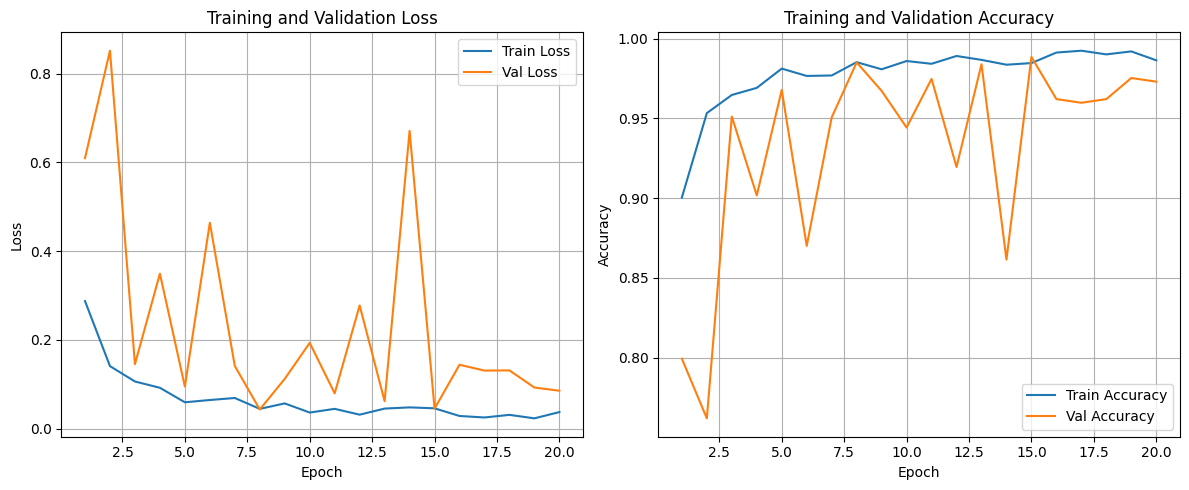

In [11]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)

In [12]:
ckpt = torch.load("models/saved_models/aug_model.pth", map_location=device)
aug_model.load_state_dict(ckpt["model_state_dict"])
aug_model.to(device)


recall_per_class, accuracy, val_loss = eval_epoch(aug_model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.8070
Test Recall per class:
Class 0 (Bellis perennis): 0.6549
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0050
Class 5 (Hieracium umbellatum): 0.8450
Class 6 (Hypochaeris radicata): 0.8350
Class 7 (Sonchus arvensis): 0.8383
Class 8 (Tragopogon pratensis): 0.9699
Class 9 (Tussilago farfara): 1.0000


## TEST 2


In [13]:
from Data_Utility.augmented_dataset import AugmentedPollenDataset
from Data_Utility.dataset import PollenFolderWithSizeDataset

augmented_train_dataset = AugmentedPollenDataset(
    img_dir=train_dir,
    class_to_idx=class_to_idx,
    size_lookup=size_lookup,
    species_mean_lookup=species_mean_lookup,
    fill_missing_bool=True,        
    transform_base=base_transform,
    transform_aug=aug_transform,
    augment=True,
    n_max=1000, # Set a fixed n_max for all classes
    seed=42,
    shuffle_final=True,
    print_summary=True,
)

augmented_test_dataset = AugmentedPollenDataset(
    img_dir=test_dir,
    class_to_idx=class_to_idx,
    size_lookup=size_lookup,
    species_mean_lookup=species_mean_lookup,
    fill_missing_bool=False,        
    transform_base=base_transform,
    transform_aug=None,
    augment=False,
    seed=42,
    shuffle_final=True,
    print_summary=True,
)



Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 1922
Final dataset size: 10000
Target per-class size (n_max): 1000
Per-class original sizes:
  Bellis perennis: 858 (add 142)
  Brassica napus: 800 (add 200)
  Capsella bursa-pastoris: 817 (add 183)
  Cichorium intybus: 870 (add 130)
  Crepis capillaris: 800 (add 200)
  Hieracium umbellatum: 800 (a

In [14]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(augmented_train_dataset))
val_size = len(augmented_train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
augmented_train_subset, augmented_val_subset = random_split(augmented_train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(augmented_train_subset)}")
print(f"Validation subset size: {len(augmented_val_subset)}")

Train subset size: 8000
Validation subset size: 2000


In [15]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
aug1000_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(aug_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [16]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    aug_model,
    augmented_train_subset,
    augmented_val_subset,
    augmented_test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="aug1000_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 250/250 [00:25<00:00,  9.62it/s]


Epoch 1/20 | Train Loss: 0.0643, Train Acc: 0.9801 | Val Loss: 0.2163, Val Acc: 0.9340
Val Recall per class: tensor([0.9889, 0.8763, 1.0000, 0.6066, 0.9171, 0.9904, 0.9951, 1.0000, 0.9799,
        1.0000])
Saved new best model (Val Acc = 0.9340)


100%|██████████| 250/250 [00:26<00:00,  9.58it/s]


Epoch 2/20 | Train Loss: 0.0532, Train Acc: 0.9820 | Val Loss: 0.1977, Val Acc: 0.9410
Saved new best model (Val Acc = 0.9410)


100%|██████████| 250/250 [00:26<00:00,  9.61it/s]


...

Epoch 15/20 | Train Loss: 0.0188, Train Acc: 0.9925 | Val Loss: 0.0680, Val Acc: 0.9800
Val Recall per class: tensor([0.9944, 0.9946, 0.9845, 0.8957, 0.9902, 1.0000, 0.9458, 1.0000, 1.0000,
        1.0000])


100%|██████████| 250/250 [00:26<00:00,  9.55it/s]


Epoch 16/20 | Train Loss: 0.0178, Train Acc: 0.9938 | Val Loss: 0.0387, Val Acc: 0.9880


100%|██████████| 250/250 [00:25<00:00,  9.62it/s]


Epoch 17/20 | Train Loss: 0.0341, Train Acc: 0.9901 | Val Loss: 0.1574, Val Acc: 0.9490
Early stopping at epoch 17. Best Val Acc = 0.9885 at epoch 9.
Reloaded best model from epoch 9 (Val Acc=0.9885)


In [17]:
ckpt = torch.load("models/saved_models/aug1000_model.pth", map_location=device)
aug1000_model.load_state_dict(ckpt["model_state_dict"])
aug1000_model.to(device)

recall_per_class, accuracy, val_loss = eval_epoch(aug1000_model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.7341
Test Recall per class:
Class 0 (Bellis perennis): 0.0493
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9945
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.1300
Class 5 (Hieracium umbellatum): 0.9550
Class 6 (Hypochaeris radicata): 0.4300
Class 7 (Sonchus arvensis): 0.7814
Class 8 (Tragopogon pratensis): 0.9699
Class 9 (Tussilago farfara): 1.0000


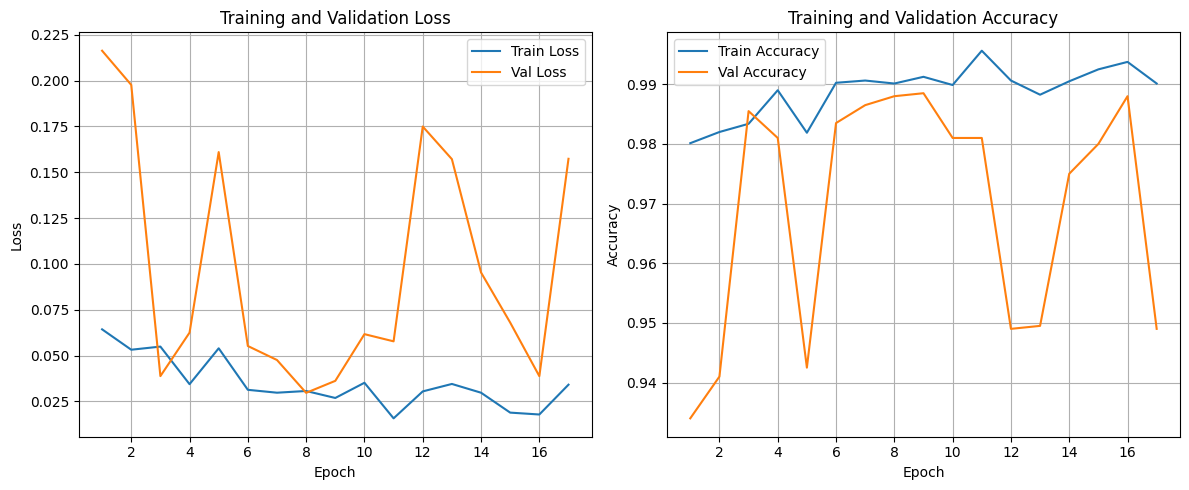

In [18]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)

## Apply weighted cross-entropy 

### Frequency weighted

In [19]:

size_lookup, species_mean_lookup, global_mean = lookup_size_from_excel(test_excel_path)

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
#train_tf = T.Compose([T.ToTensor()]) # converts PIL → Tensor
#test_tf = T.Compose([T.ToTensor()]) # converts PIL → Tensor

train_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = PollenFolderWithSizeDataset(img_dir=train_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, transform=train_tf)
test_dataset = PollenFolderWithSizeDataset(img_dir=test_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, transform=test_tf)




Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.


In [20]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")

Train subset size: 6337
Validation subset size: 1585


In [21]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
model = CNNWithSizeMLP().to(device)

counts = train_dataset.get_class_counts(device=device)  # shape [K]

# Inverse frequency weights
K = counts.numel()
N = counts.sum().item()
weights = (N / (K * counts.float().clamp(min=1.0))).to(device)

loss_fn = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [22]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    model,
    train_subset,
    val_subset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="weightfre_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 199/199 [00:17<00:00, 11.08it/s]


Epoch 1/20 | Train Loss: 0.3197, Train Acc: 0.8984 | Val Loss: 0.3587, Val Acc: 0.8820
Val Recall per class: tensor([0.8242, 0.9392, 0.9806, 0.8261, 0.9507, 0.6899, 0.9051, 0.8209, 1.0000,
        0.8841])
Saved new best model (Val Acc = 0.8820)


100%|██████████| 199/199 [00:18<00:00, 11.02it/s]


Epoch 2/20 | Train Loss: 0.1337, Train Acc: 0.9590 | Val Loss: 0.5984, Val Acc: 0.8909
Saved new best model (Val Acc = 0.8909)


100%|██████████| 199/199 [00:18<00:00, 11.03it/s]


...

Epoch 13/20 | Train Loss: 0.0495, Train Acc: 0.9946 | Val Loss: 0.1245, Val Acc: 0.9621


100%|██████████| 199/199 [00:17<00:00, 11.06it/s]


Epoch 14/20 | Train Loss: 0.0651, Train Acc: 0.9883 | Val Loss: 0.1221, Val Acc: 0.9621


100%|██████████| 199/199 [00:18<00:00, 11.05it/s]


Epoch 15/20 | Train Loss: 0.0802, Train Acc: 0.9826 | Val Loss: 0.6841, Val Acc: 0.8644
Val Recall per class: tensor([1.0000, 0.7845, 1.0000, 1.0000, 0.7042, 0.7152, 0.8905, 0.4552, 0.9939,
        1.0000])
Early stopping at epoch 15. Best Val Acc = 0.9880 at epoch 7.
Reloaded best model from epoch 7 (Val Acc=0.9880)


In [23]:
ckpt = torch.load("models/saved_models/weightfre_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss = eval_epoch(model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.7482
Test Recall per class:
Class 0 (Bellis perennis): 0.9366
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9950
Class 6 (Hypochaeris radicata): 0.4450
Class 7 (Sonchus arvensis): 0.5419
Class 8 (Tragopogon pratensis): 0.9398
Class 9 (Tussilago farfara): 1.0000


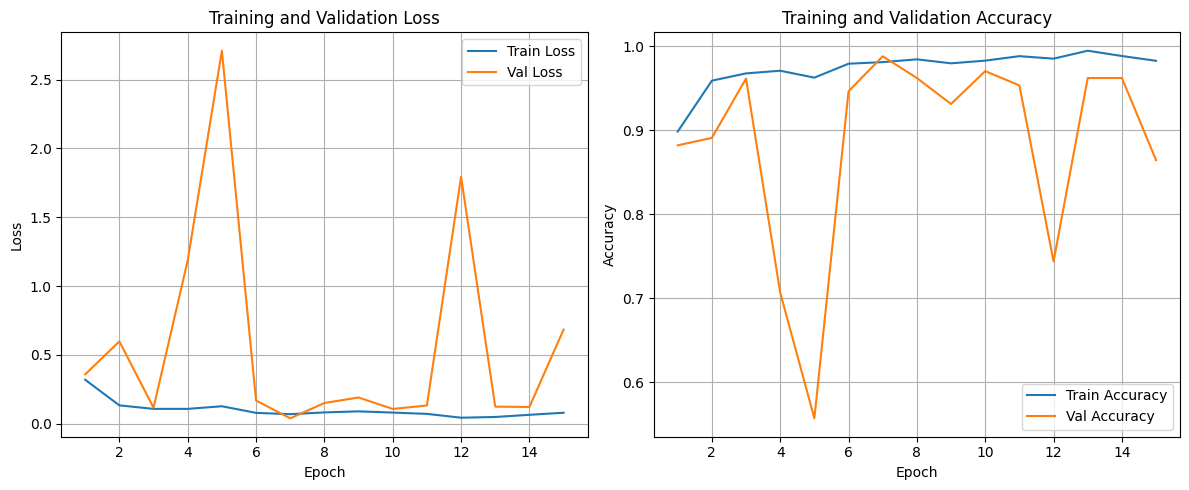

In [24]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)

## Frequency weighted + Augmentation

In [27]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
freg_aug_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

counts = train_dataset.get_class_counts(device=device)  # shape [K]

# Inverse frequency weights
K = counts.numel()
N = counts.sum().item()
weights = (N / (K * counts.float().clamp(min=1.0))).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(freg_aug_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [28]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    freg_aug_model,
    augmented_train_subset,
    augmented_val_subset,
    augmented_test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="freg_aug_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 250/250 [00:26<00:00,  9.43it/s]


Epoch 1/20 | Train Loss: 0.2995, Train Acc: 0.9019 | Val Loss: 3.1776, Val Acc: 0.5205
Val Recall per class: tensor([0.9944, 0.4140, 1.0000, 0.2322, 0.7951, 0.0478, 0.1576, 0.0000, 0.9950,
        0.7056])
Saved new best model (Val Acc = 0.5205)


100%|██████████| 250/250 [00:25<00:00,  9.66it/s]


Epoch 2/20 | Train Loss: 0.1392, Train Acc: 0.9533 | Val Loss: 0.2182, Val Acc: 0.9225
Saved new best model (Val Acc = 0.9225)


100%|██████████| 250/250 [00:26<00:00,  9.45it/s]


...

Epoch 18/20 | Train Loss: 0.0247, Train Acc: 0.9922 | Val Loss: 0.7870, Val Acc: 0.8420


100%|██████████| 250/250 [00:26<00:00,  9.57it/s]


Epoch 19/20 | Train Loss: 0.0478, Train Acc: 0.9851 | Val Loss: 0.0991, Val Acc: 0.9680


100%|██████████| 250/250 [00:26<00:00,  9.57it/s]


Epoch 20/20 | Train Loss: 0.0191, Train Acc: 0.9936 | Val Loss: 0.1225, Val Acc: 0.9620
Val Recall per class: tensor([1.0000, 0.9194, 1.0000, 0.9005, 0.9024, 0.9617, 0.9458, 1.0000, 0.9950,
        1.0000])
Reloaded best model from epoch 16 (Val Acc=0.9850)


In [29]:
ckpt = torch.load("models/saved_models/freg_aug_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss = eval_epoch(freg_aug_model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.8075
Test Recall per class:
Class 0 (Bellis perennis): 0.9648
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9945
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0400
Class 5 (Hieracium umbellatum): 0.9800
Class 6 (Hypochaeris radicata): 0.6100
Class 7 (Sonchus arvensis): 0.7695
Class 8 (Tragopogon pratensis): 0.9217
Class 9 (Tussilago farfara): 1.0000


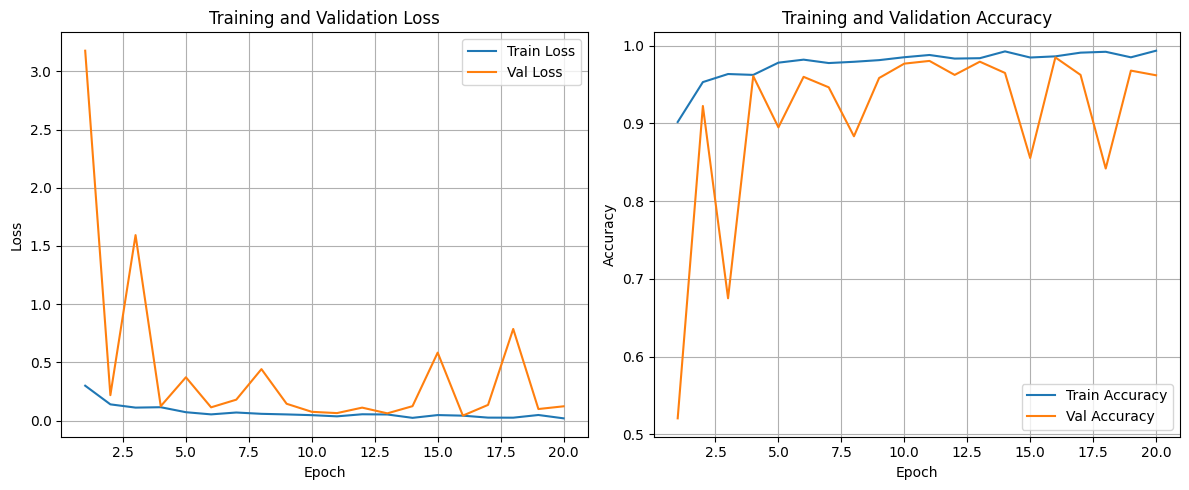

In [30]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)

## Frequency weighted + Augmentation 1000

In [31]:
from Data_Utility.augmented_dataset import AugmentedPollenDataset
from Data_Utility.dataset import PollenFolderWithSizeDataset

augmented1000_train_dataset = AugmentedPollenDataset(
    img_dir=train_dir,
    class_to_idx=class_to_idx,
    size_lookup=size_lookup,
    species_mean_lookup=species_mean_lookup,
    fill_missing_bool=True,        
    transform_base=base_transform,
    transform_aug=aug_transform,
    augment=True,
    n_max=1000, # Set a fixed n_max for all classes
    seed=42,
    shuffle_final=True,
    print_summary=True,
)

augmented_test_dataset = AugmentedPollenDataset(
    img_dir=test_dir,
    class_to_idx=class_to_idx,
    size_lookup=size_lookup,
    species_mean_lookup=species_mean_lookup,
    fill_missing_bool=False,        
    transform_base=base_transform,
    transform_aug=None,
    augment=False,
    seed=42,
    shuffle_final=True,
    print_summary=True,
)



Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 1922
Final dataset size: 10000
Target per-class size (n_max): 1000
Per-class original sizes:
  Bellis perennis: 858 (add 142)
  Brassica napus: 800 (add 200)
  Capsella bursa-pastoris: 817 (add 183)
  Cichorium intybus: 870 (add 130)
  Crepis capillaris: 800 (add 200)
  Hieracium umbellatum: 800 (a

In [32]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(augmented1000_train_dataset))
val_size = len(augmented1000_train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
augmented1000_train_subset, augmented1000_val_subset = random_split(augmented1000_train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(augmented1000_train_subset)}")
print(f"Validation subset size: {len(augmented1000_val_subset)}")

Train subset size: 8000
Validation subset size: 2000


In [33]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
freg_aug1000_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

counts = train_dataset.get_class_counts(device=device)  # shape [K]

# Inverse frequency weights
K = counts.numel()
N = counts.sum().item()
weights = (N / (K * counts.float().clamp(min=1.0))).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(freg_aug1000_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [34]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    freg_aug1000_model,
    augmented1000_train_subset,
    augmented1000_val_subset,
    augmented_test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="freg_aug1000_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 250/250 [00:26<00:00,  9.56it/s]


Epoch 1/20 | Train Loss: 0.2887, Train Acc: 0.9042 | Val Loss: 0.8635, Val Acc: 0.7360
Val Recall per class: tensor([0.4333, 0.9731, 0.7784, 0.9905, 0.3171, 0.8565, 0.8670, 0.8287, 0.3317,
        0.9543])
Saved new best model (Val Acc = 0.7360)


100%|██████████| 250/250 [00:26<00:00,  9.49it/s]


Epoch 2/20 | Train Loss: 0.1656, Train Acc: 0.9480 | Val Loss: 1.7959, Val Acc: 0.6000


100%|██████████| 250/250 [00:25<00:00,  9.63it/s]


...

Epoch 18/20 | Train Loss: 0.0215, Train Acc: 0.9921 | Val Loss: 0.1221, Val Acc: 0.9685


100%|██████████| 250/250 [00:26<00:00,  9.61it/s]


Epoch 19/20 | Train Loss: 0.0415, Train Acc: 0.9869 | Val Loss: 1.1427, Val Acc: 0.8025


100%|██████████| 250/250 [00:25<00:00,  9.67it/s]


Epoch 20/20 | Train Loss: 0.0209, Train Acc: 0.9936 | Val Loss: 0.0481, Val Acc: 0.9850
Val Recall per class: tensor([1.0000, 0.9785, 0.9948, 1.0000, 0.9268, 0.9761, 0.9951, 0.9815, 1.0000,
        1.0000])
Reloaded best model from epoch 14 (Val Acc=0.9905)


In [35]:
ckpt = torch.load("models/saved_models/freg_aug1000_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss = eval_epoch(freg_aug1000_model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.7846
Test Recall per class:
Class 0 (Bellis perennis): 0.4648
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9945
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0650
Class 5 (Hieracium umbellatum): 0.9750
Class 6 (Hypochaeris radicata): 0.5800
Class 7 (Sonchus arvensis): 0.8174
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


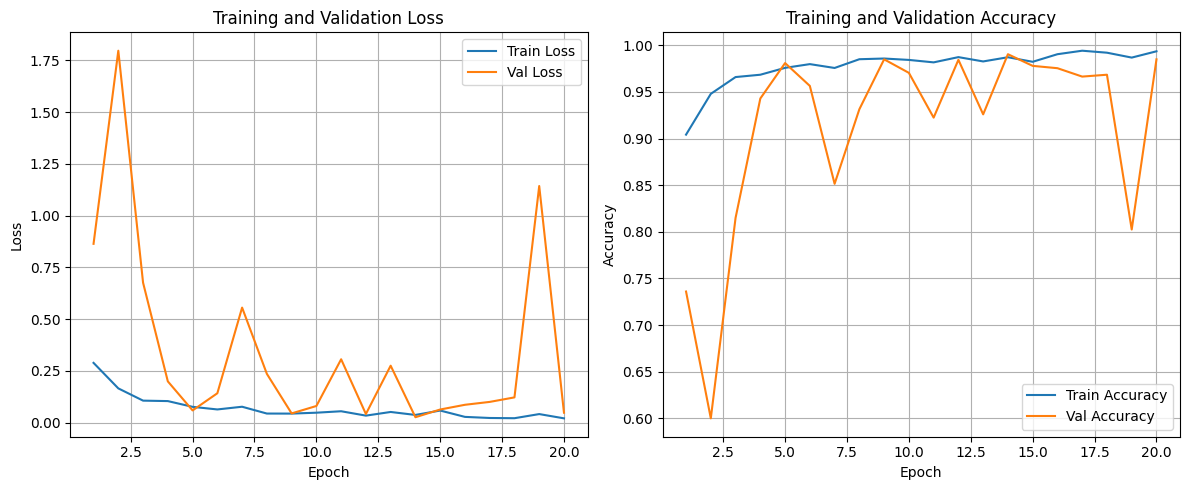

In [36]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)

## Effective number of samples weighting

In [37]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
effB_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

class_weights = train_dataset.get_effective_num_weights(
    beta=0.9,
    device=device
)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(effB_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [38]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    effB_model,
    train_subset,
    val_subset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="effB_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 199/199 [00:18<00:00, 10.95it/s]


Epoch 1/20 | Train Loss: 0.3232, Train Acc: 0.8902 | Val Loss: 4.9796, Val Acc: 0.3937
Val Recall per class: tensor([0.9879, 0.6796, 0.8774, 0.0000, 0.0915, 0.1582, 0.0146, 0.2388, 0.5333,
        0.2561])
Saved new best model (Val Acc = 0.3937)


100%|██████████| 199/199 [00:18<00:00, 11.02it/s]


Epoch 2/20 | Train Loss: 0.1781, Train Acc: 0.9487 | Val Loss: 0.4119, Val Acc: 0.8580
Saved new best model (Val Acc = 0.8580)


100%|██████████| 199/199 [00:18<00:00, 11.02it/s]


...

Epoch 9/20 | Train Loss: 0.0694, Train Acc: 0.9869 | Val Loss: 0.0891, Val Acc: 0.9716


100%|██████████| 199/199 [00:18<00:00, 11.00it/s]


Epoch 10/20 | Train Loss: 0.0717, Train Acc: 0.9771 | Val Loss: 0.2927, Val Acc: 0.9281
Val Recall per class: tensor([0.9879, 1.0000, 0.9742, 1.0000, 0.9930, 0.9304, 0.8613, 0.4254, 1.0000,
        1.0000])


100%|██████████| 199/199 [00:18<00:00, 10.99it/s]


Epoch 11/20 | Train Loss: 0.0512, Train Acc: 0.9913 | Val Loss: 0.2927, Val Acc: 0.9104
Early stopping at epoch 11. Best Val Acc = 0.9811 at epoch 3.
Reloaded best model from epoch 3 (Val Acc=0.9811)


In [39]:
ckpt = torch.load("models/saved_models/effB_model.pth", map_location=device)
effB_model.load_state_dict(ckpt["model_state_dict"])
effB_model.to(device)

recall_per_class, accuracy, val_loss = eval_epoch(effB_model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.7997
Test Recall per class:
Class 0 (Bellis perennis): 0.9930
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9945
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.6900
Class 6 (Hypochaeris radicata): 0.6250
Class 7 (Sonchus arvensis): 0.8772
Class 8 (Tragopogon pratensis): 0.9699
Class 9 (Tussilago farfara): 1.0000


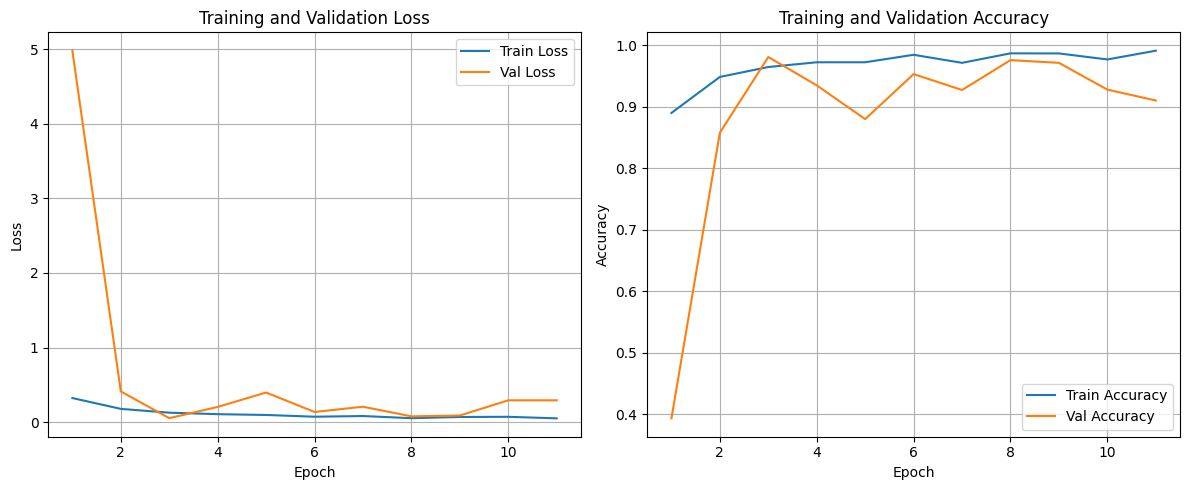

In [40]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)

## ANother test

In [41]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
effB_aug_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

class_weights = train_dataset.get_effective_num_weights(
    beta=0.9,
    device=device
)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(effB_aug_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [42]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    effB_aug_model,
    augmented_train_subset,
    augmented_val_subset,
    augmented_test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="effB_aug_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 250/250 [00:26<00:00,  9.54it/s]


Epoch 1/20 | Train Loss: 0.3273, Train Acc: 0.8925 | Val Loss: 1.4831, Val Acc: 0.7315
Val Recall per class: tensor([0.6000, 0.9946, 0.9433, 0.0284, 0.9707, 0.1483, 0.8571, 1.0000, 0.8744,
        0.9492])
Saved new best model (Val Acc = 0.7315)


100%|██████████| 250/250 [00:26<00:00,  9.58it/s]


Epoch 2/20 | Train Loss: 0.1462, Train Acc: 0.9517 | Val Loss: 0.7486, Val Acc: 0.7645
Saved new best model (Val Acc = 0.7645)


100%|██████████| 250/250 [00:26<00:00,  9.56it/s]


...

Epoch 14/20 | Train Loss: 0.0524, Train Acc: 0.9828 | Val Loss: 0.2399, Val Acc: 0.9290


100%|██████████| 250/250 [00:26<00:00,  9.56it/s]


Epoch 15/20 | Train Loss: 0.0389, Train Acc: 0.9866 | Val Loss: 0.9863, Val Acc: 0.7870
Val Recall per class: tensor([0.9333, 1.0000, 0.9485, 0.9953, 0.3659, 0.8278, 1.0000, 0.6111, 0.2462,
        0.9848])


100%|██████████| 250/250 [00:26<00:00,  9.60it/s]


Epoch 16/20 | Train Loss: 0.0322, Train Acc: 0.9891 | Val Loss: 0.0376, Val Acc: 0.9855
Early stopping at epoch 16. Best Val Acc = 0.9865 at epoch 8.
Reloaded best model from epoch 8 (Val Acc=0.9865)


In [43]:
ckpt = torch.load("models/saved_models/effB_aug_model.pth", map_location=device)
effB_model.load_state_dict(ckpt["model_state_dict"])
effB_model.to(device)

recall_per_class, accuracy, val_loss = eval_epoch(effB_aug_model, test_loader, device, recall_metric, accuracy_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

Test Accuracy: 0.7409
Test Recall per class:
Class 0 (Bellis perennis): 0.7254
Class 1 (Brassica napus): 0.9600
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 0.9923
Class 4 (Crepis capillaris): 0.1250
Class 5 (Hieracium umbellatum): 0.9400
Class 6 (Hypochaeris radicata): 0.4300
Class 7 (Sonchus arvensis): 0.5539
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


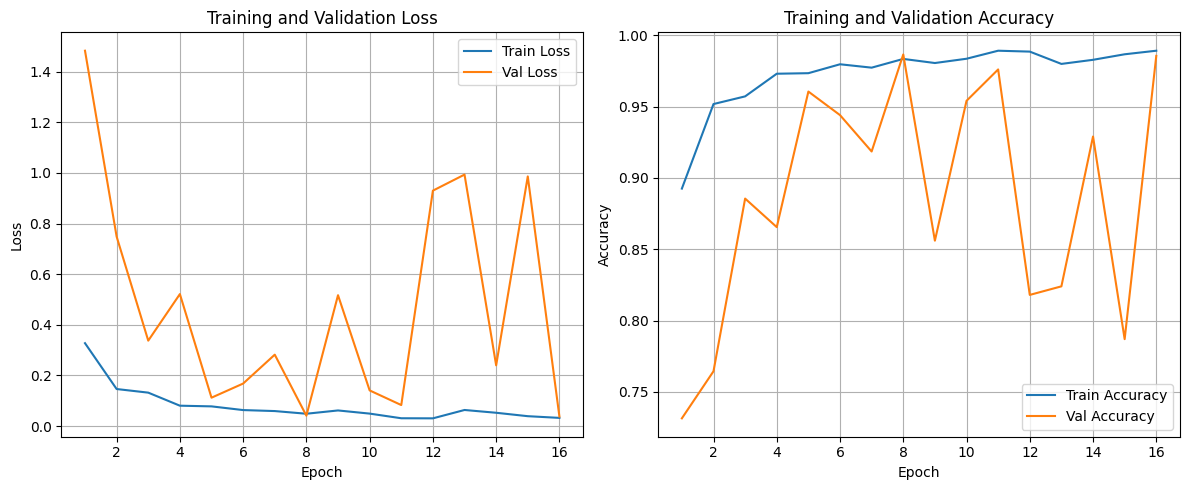

In [44]:
epochs_ran = len(history["train_loss"])

plot_training_history(history, epochs_ran)